# SentinelVision AI
## Notebook 03 — Feature Extraction with VideoMAE

### Objective

Notebook 01 analyzed dataset metadata.

Notebook 02 inspected the real video content.

The first feature extraction version used simple RGB and grayscale statistics.

This upgraded version uses a pretrained VideoMAE model as a frozen feature extractor.

The flow is:

`clip manifest → balanced clip sample → sample video frames → VideoMAE embeddings → saved embedding table`

The output is saved separately as:

`data/embeddings/clip_embeddings_videomae_sample.parquet`

This keeps the original statistical embedding file available for comparison.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel

c:\Users\tevin\OneDrive\Desktop\Computer-Vision\SentinelVision-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We are still not fine-tuning a model.

We are using VideoMAE as a frozen feature extractor.

That means:

`video clip → pretrained video model → embedding vector`

The anomaly models in Notebook 04 and Notebook 05 will train on these stronger embeddings.

In [2]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

device

device(type='cpu')

#### Load clip manifest

In [3]:
metadata_dir = Path("../data/metadata")
embeddings_dir = Path("../data/embeddings")

embeddings_dir.mkdir(
    parents=True,
    exist_ok=True,
)

clip_manifest = pd.read_parquet(
    metadata_dir / "clip_manifest.parquet"
)

clip_manifest.shape

(44996, 12)

In [4]:
clip_manifest.head()

,clip_id,video_id,file_path,category,binary_label,split,clip_index,start_seconds,end_seconds,clip_duration_seconds,source_video_duration_seconds,source_fps
0,Abuse002_x264_clip_00000,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,0,0.0,4.0,4.0,28.833,30.0
1,Abuse002_x264_clip_00001,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,1,4.0,8.0,4.0,28.833,30.0
2,Abuse002_x264_clip_00002,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,2,8.0,12.0,4.0,28.833,30.0
3,Abuse002_x264_clip_00003,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,3,12.0,16.0,4.0,28.833,30.0
4,Abuse002_x264_clip_00004,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,4,16.0,20.0,4.0,28.833,30.0


#### Resolve video paths

In [5]:
project_root = Path("..").resolve()


def resolve_video_path(file_path: str) -> Path:
    """
    Convert a stored video path into an absolute path.
    """
    path = Path(file_path)

    if path.is_absolute():
        return path

    return project_root / path

In [6]:
example_path = resolve_video_path(
    clip_manifest.iloc[0]["file_path"]
)

print(example_path)
print("Exists:", example_path.exists())

C:\Users\tevin\OneDrive\Desktop\Computer-Vision\SentinelVision-AI\data\raw\ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos-Part-1\Abuse\Abuse002_x264.mp4
Exists: True


#### Create a balanced VideoMAE extraction sample

Start here from the old Notebook 03.

We keep the same balanced sampling logic so Notebook 04 and Notebook 05 remain fair.

Start with 100 normal and 100 anomalous clips per split.

After this works, we can increase the sample size.

In [7]:
sample_per_label_per_split = 100

clip_sample = (
    clip_manifest
    .groupby(["split", "binary_label"], group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(len(group), sample_per_label_per_split),
            random_state=seed,
        )
    )
    .reset_index(drop=True)
)

print("Sample shape:", clip_sample.shape)
print()
print(clip_sample.groupby(["split", "binary_label"]).size())

Sample shape: (600, 12)

split       binary_label
test        0               100
            1               100
train       0               100
            1               100
validation  0               100
            1               100
dtype: int64


C:\Users\tevin\AppData\Local\Temp\ipykernel_12840\3328362982.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


#### Frame sampling functions

VideoMAE expects a fixed number of frames.

For each 4-second clip, we sample 16 evenly spaced frames.

If a clip returns fewer frames, we repeat the last available frame so the model still receives 16 frames.

In [8]:
def read_frame_at_time(
    video_path: str | Path,
    timestamp_seconds: float,
) -> np.ndarray | None:
    """
    Read one RGB frame from a video at a specific timestamp.
    """
    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        capture.release()
        return None

    capture.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp_seconds * 1000,
    )

    success, frame = capture.read()
    capture.release()

    if not success or frame is None:
        return None

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    return frame_rgb


def sample_clip_frames(
    video_path: str | Path,
    start_seconds: float,
    end_seconds: float,
    number_of_frames: int = 16,
) -> list[np.ndarray]:
    """
    Sample evenly spaced frames from one clip window.
    """
    if end_seconds <= start_seconds:
        return []

    timestamps = np.linspace(
        start_seconds,
        max(end_seconds - 0.05, start_seconds),
        number_of_frames,
    )

    frames = []

    for timestamp in timestamps:
        frame = read_frame_at_time(
            video_path=video_path,
            timestamp_seconds=float(timestamp),
        )

        if frame is not None:
            frames.append(frame)

    return frames


def ensure_frame_count(
    frames: list[np.ndarray],
    number_of_frames: int = 16,
) -> list[np.ndarray]:
    """
    Make sure every clip has exactly the number of frames VideoMAE expects.
    """
    if len(frames) == 0:
        return []

    if len(frames) > number_of_frames:
        selected_indices = np.linspace(
            0,
            len(frames) - 1,
            number_of_frames,
        ).astype(int)

        frames = [
            frames[index]
            for index in selected_indices
        ]

    while len(frames) < number_of_frames:
        frames.append(frames[-1])

    return frames

#### Load VideoMAE as a frozen feature extractor

We use the pretrained Hugging Face model without fine-tuning.

The model produces stronger video-aware embeddings than simple RGB statistics.

In [9]:
model_name = "MCG-NJU/videomae-base-finetuned-kinetics"

processor = AutoImageProcessor.from_pretrained(
    model_name,
)

videomae_model = AutoModel.from_pretrained(
    model_name,
).to(device)

videomae_model.eval()

model_name

Loading weights: 100%|██████████| 158/158 [00:00<00:00, 7506.88it/s]
[transformers] VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key                                                        | Status     | 
-----------------------------------------------------------+------------+-
videomae.encoder.layer.{0...11}.attention.attention.v_bias | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.q_bias | UNEXPECTED | 
fc_norm.weight                                             | UNEXPECTED | 
classifier.weight                                          | UNEXPECTED | 
fc_norm.bias                                               | UNEXPECTED | 
classifier.bias                                            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias        | MISSING    | 
encoder.layer.{0...11}.attention.attention.query.bias      | MISSING    | 
encoder.layer.{0...11}.attention.attention.value.bias      | MISSING    | 

Notes:
- UNEXPECT

'MCG-NJU/videomae-base-finetuned-kinetics'

#### Convert one clip into one VideoMAE embedding

The model returns hidden states for video patches.

We average those hidden states into one clip-level embedding.

That gives one numeric vector per clip.

In [10]:
def clip_to_videomae_embedding(
    video_path: str | Path,
    start_seconds: float,
    end_seconds: float,
    number_of_frames: int = 16,
) -> np.ndarray | None:
    """
    Convert one clip window into one VideoMAE embedding.
    """
    frames = sample_clip_frames(
        video_path=video_path,
        start_seconds=start_seconds,
        end_seconds=end_seconds,
        number_of_frames=number_of_frames,
    )

    frames = ensure_frame_count(
        frames=frames,
        number_of_frames=number_of_frames,
    )

    if not frames:
        return None

    inputs = processor(
        frames,
        return_tensors="pt",
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = videomae_model(**inputs)

    # Mean-pool patch tokens into one clip-level embedding.
    embedding = outputs.last_hidden_state.mean(dim=1)

    embedding = embedding.squeeze(0).cpu().numpy()

    return embedding

#### Test VideoMAE extraction on one clip

In [11]:
test_clip = clip_sample.iloc[0]

test_video_path = resolve_video_path(
    test_clip["file_path"]
)

test_embedding = clip_to_videomae_embedding(
    video_path=test_video_path,
    start_seconds=test_clip["start_seconds"],
    end_seconds=test_clip["end_seconds"],
    number_of_frames=16,
)

print("Embedding shape:", test_embedding.shape if test_embedding is not None else None)
print("First 5 values:", test_embedding[:5] if test_embedding is not None else None)

Embedding shape: (768,)
First 5 values: [ 0.17876922  3.7290657   3.666701    4.326803   -1.9802929 ]


#### Extract VideoMAE embeddings for sampled clips

This is the slowest cell.

It reads real video clips, samples frames, runs VideoMAE, and saves one embedding per clip.

In [12]:
embedding_records = []

for row in tqdm(
    clip_sample.itertuples(index=False),
    total=len(clip_sample),
    desc="Extracting VideoMAE embeddings",
):
    video_path = resolve_video_path(row.file_path)

    embedding = clip_to_videomae_embedding(
        video_path=video_path,
        start_seconds=row.start_seconds,
        end_seconds=row.end_seconds,
        number_of_frames=16,
    )

    if embedding is None:
        continue

    record = {
        "clip_id": row.clip_id,
        "video_id": row.video_id,
        "category": row.category,
        "binary_label": row.binary_label,
        "split": row.split,
        "start_seconds": row.start_seconds,
        "end_seconds": row.end_seconds,
    }

    for index, value in enumerate(embedding):
        record[f"feature_{index:03d}"] = float(value)

    embedding_records.append(record)

videomae_embeddings = pd.DataFrame(embedding_records)

videomae_embeddings.shape

Extracting VideoMAE embeddings: 100%|██████████| 600/600 [30:14<00:00,  3.02s/it]


(600, 775)

In [13]:
videomae_embeddings.head()

,clip_id,video_id,category,binary_label,split,start_seconds,end_seconds,feature_000,feature_001,feature_002,...,feature_758,feature_759,feature_760,feature_761,feature_762,feature_763,feature_764,feature_765,feature_766,feature_767
0,Normal_Videos_365_x264_clip_00003,Normal_Videos_365_x264,Normal,0,test,12.0,16.0,0.178769,3.729066,3.666701,...,2.413040,-1.240642,-1.159237,-1.608377,3.872948,1.565241,0.879731,0.846557,-1.191670,-0.930276
1,Normal_Videos_365_x264_clip_00030,Normal_Videos_365_x264,Normal,0,test,120.0,124.0,0.278189,2.779260,3.542873,...,-0.741295,-1.844295,0.887464,0.550726,3.069808,1.138670,1.094854,0.417987,-1.605511,1.888869
2,Normal_Videos_365_x264_clip_00032,Normal_Videos_365_x264,Normal,0,test,128.0,132.0,0.229807,3.365491,3.970525,...,1.338005,-2.018188,-0.082708,-0.061900,3.764704,1.424313,0.843749,1.016206,-1.329999,1.080641
3,Normal_Videos_641_x264_clip_00015,Normal_Videos_641_x264,Normal,0,test,60.0,64.0,-5.002384,1.898196,0.756616,...,-2.385197,0.084327,4.650817,3.130729,2.914249,-0.534147,2.499364,3.860784,0.763254,-1.158123
4,Normal_Videos_312_x264_clip_00000,Normal_Videos_312_x264,Normal,0,test,0.0,4.0,-4.661326,1.897303,1.866576,...,0.865088,-1.091096,1.328566,4.970067,2.660053,1.487340,2.988191,1.090254,0.692304,0.847159


#### Check extraction coverage

In [14]:
requested_clips = len(clip_sample)
extracted_clips = len(videomae_embeddings)

coverage = extracted_clips / requested_clips

print(f"Requested clips: {requested_clips:,}")
print(f"Extracted clips: {extracted_clips:,}")
print(f"Coverage: {coverage:.2%}")

print()
print(videomae_embeddings.groupby(["split", "binary_label"]).size())

Requested clips: 600
Extracted clips: 600
Coverage: 100.00%

split       binary_label
test        0               100
            1               100
train       0               100
            1               100
validation  0               100
            1               100
dtype: int64


#### Inspect VideoMAE embedding columns

In [15]:
feature_columns = [
    column
    for column in videomae_embeddings.columns
    if column.startswith("feature_")
]

print("Number of feature columns:", len(feature_columns))
print(feature_columns[:10])

Number of feature columns: 768
['feature_000', 'feature_001', 'feature_002', 'feature_003', 'feature_004', 'feature_005', 'feature_006', 'feature_007', 'feature_008', 'feature_009']


In [16]:
videomae_embeddings[feature_columns].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
feature_000,600.0,-1.448423,1.803554,-6.951325,-2.572877,-1.459343,-0.280148,4.807185
feature_001,600.0,0.817601,1.906601,-4.481095,-0.530333,0.979028,2.180941,5.711024
feature_002,600.0,0.578219,1.958169,-5.391392,-0.833589,0.462517,2.026579,6.468427
feature_003,600.0,1.640094,2.039617,-3.506546,0.412616,1.682693,3.005878,7.609078
feature_004,600.0,-1.110559,1.630534,-5.606266,-2.157554,-1.225644,-0.152631,4.530379
feature_005,600.0,-0.815248,1.698439,-5.165660,-2.019518,-0.867635,0.516100,5.476959
feature_006,600.0,0.501910,1.628680,-4.715062,-0.571093,0.439598,1.566841,4.581321
feature_007,600.0,1.236438,1.783367,-3.215537,0.010053,1.402026,2.576785,5.395766
feature_008,600.0,-0.259390,1.791261,-5.047559,-1.550604,-0.064211,0.901863,5.255990
feature_009,600.0,-0.521791,1.819913,-5.319885,-1.787867,-0.397249,0.637762,4.765369


#### Save VideoMAE sample embeddings

We save this as a new file.

Do not overwrite the original statistical embedding file.

In [17]:
videomae_embeddings_path = (
    embeddings_dir / "clip_embeddings_videomae_sample.parquet"
)

videomae_embeddings.to_parquet(
    videomae_embeddings_path,
    index=False,
)

videomae_embeddings_path

WindowsPath('../data/embeddings/clip_embeddings_videomae_sample.parquet')

In [18]:
saved = pd.read_parquet(videomae_embeddings_path)

print(saved.shape)
print(saved.groupby(["split", "binary_label"]).size())

(600, 775)
split       binary_label
test        0               100
            1               100
train       0               100
            1               100
validation  0               100
            1               100
dtype: int64


#### Quick visual check of VideoMAE embedding space

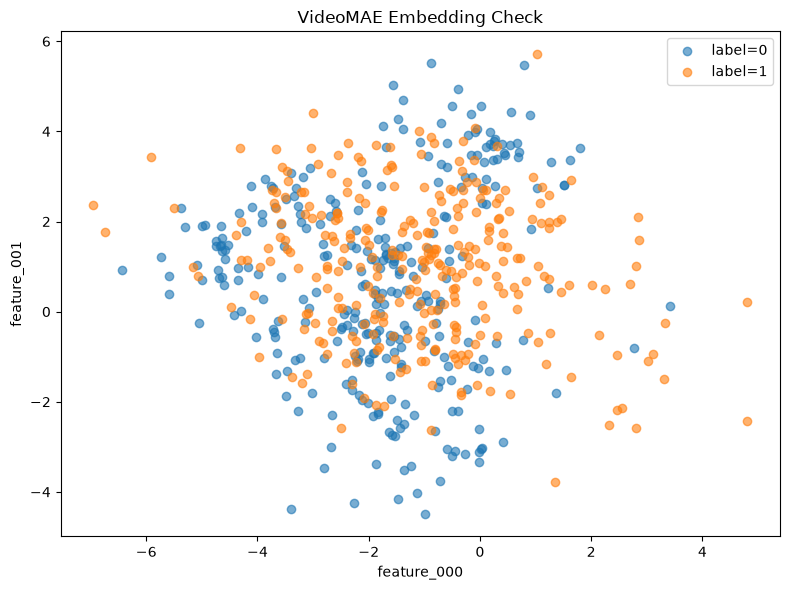

In [19]:
plt.figure(figsize=(8, 6))

for label in sorted(videomae_embeddings["binary_label"].unique()):
    subset = videomae_embeddings[
        videomae_embeddings["binary_label"] == label
    ]

    plt.scatter(
        subset["feature_000"],
        subset["feature_001"],
        label=f"label={label}",
        alpha=0.6,
    )

plt.title("VideoMAE Embedding Check")
plt.xlabel("feature_000")
plt.ylabel("feature_001")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

Notebook 03 now has a stronger feature extraction path.

## What changed

The original version used simple statistical visual features.

This upgraded version uses a pretrained VideoMAE model to extract video-aware embeddings.

## Output created

`data/embeddings/clip_embeddings_videomae_sample.parquet`

## Why this matters

The original features mostly captured brightness, color, and contrast.

VideoMAE embeddings capture richer visual and temporal patterns from the video clip.

This should give downstream anomaly models a better representation to learn from.

## Next notebooks

Rerun Notebook 04 and Notebook 05 using:

`data/embeddings/clip_embeddings_videomae_sample.parquet`

The next flow is:

`VideoMAE embeddings → baseline anomaly models → autoencoder → final comparison`